/tmp/ipykernel_61454/3281876259.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


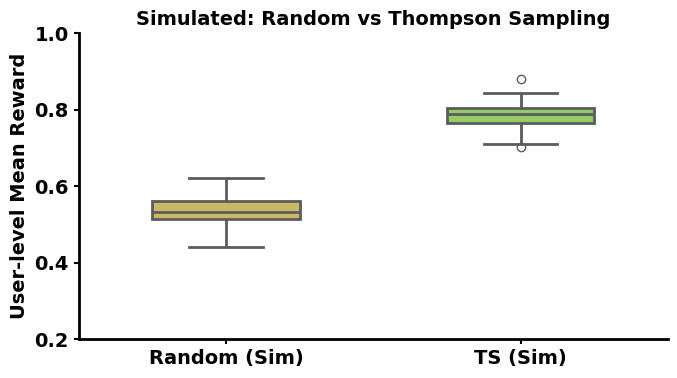

/tmp/ipykernel_61454/3281876259.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


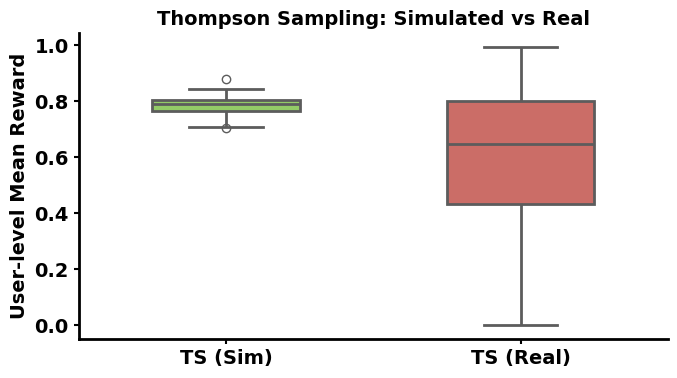

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

SMALL_SIZE = 14
MEDIUM_SIZE = 14

plt.rc('font', size=SMALL_SIZE)
plt.rc('axes', titlesize=SMALL_SIZE)
plt.rc('axes', labelsize=MEDIUM_SIZE)
plt.rc('legend', fontsize=SMALL_SIZE)
plt.rc('axes', linewidth=2)

# ===================== LOAD DATA =====================
df_random = pd.read_csv("simulated_random.csv")
df_ts_sim = pd.read_csv("simulated_ts.csv")
df_ts_real = pd.read_csv("real_world_data.csv")

# Clean real data
df_ts_real = df_ts_real[df_ts_real["Reward"].notna()]

# ===================== USER MEAN =====================
def compute_user_mean(df):
    return df.groupby("Participant_Id")["Reward"].mean().reset_index()

random_user = compute_user_mean(df_random)
ts_sim_user = compute_user_mean(df_ts_sim)
ts_real_user = compute_user_mean(df_ts_real)

# Add labels
random_user["Policy"] = "Random (Sim)"
ts_sim_user["Policy"] = "TS (Sim)"
ts_real_user["Policy"] = "TS (Real)"

# ===================== PALETTE =====================
original_palette = sns.color_palette("hls", 8)
custom_palette = [original_palette[1], original_palette[2], original_palette[0]]

#%%
# ===================== PLOT 1 =====================
df_plot1 = pd.concat([random_user, ts_sim_user])

fig, ax = plt.subplots(figsize=(7,4))

sns.boxplot(
    data=df_plot1,
    x="Policy",
    y="Reward",
    ax=ax,
    palette=[custom_palette[0], custom_palette[1]],
    linewidth=2,
    width=0.5
)

# Reduce y-axis range
ax.set_ylim(0.2, 1.0)

# Style
ax.grid(False)
plt.xticks(weight='bold')
plt.yticks(weight='bold')
plt.ylabel("User-level Mean Reward", weight='bold')
ax.set_xlabel('')
plt.title("Simulated: Random vs Thompson Sampling", weight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', width=1.5)

plt.tight_layout()
plt.savefig("plot_sim_random_vs_ts.pdf", bbox_inches='tight', dpi=300)
plt.show()


#%%
# ===================== PLOT 2 =====================
df_plot2 = pd.concat([ts_sim_user, ts_real_user])

fig, ax = plt.subplots(figsize=(7,4))

sns.boxplot(
    data=df_plot2,
    x="Policy",
    y="Reward",
    ax=ax,
    palette=[custom_palette[1], custom_palette[2]],
    linewidth=2,
    width=0.5
)

# Style
ax.grid(False)
plt.xticks(weight='bold')
plt.yticks(weight='bold')
plt.ylabel("User-level Mean Reward", weight='bold')
ax.set_xlabel('')
plt.title("Thompson Sampling: Simulated vs Real", weight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', width=1.5)

plt.tight_layout()
plt.savefig("plot_ts_sim_vs_real.pdf", bbox_inches='tight', dpi=300)
plt.show()

Data loaded
behav_df created: (34010, 3)


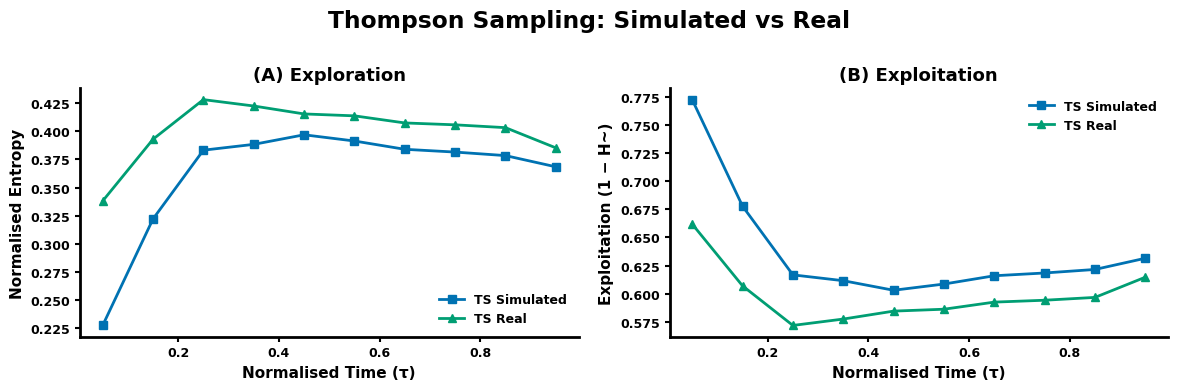

In [ ]:
#%% ===================== IMPORTS =====================
import warnings, os
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ===================== CONFIG =====================
SEED = 42
np.random.seed(SEED)

RANDOM_PATH = 'simulated_random.csv'
SIM_PATH    = 'simulated_ts.csv'
REAL_PATH   = 'real_world_data.csv'

OUT_DIR = 'analysis_outputs'
os.makedirs(OUT_DIR, exist_ok=True)

POLICY_COLORS = {
    'Random': '#E69F00',
    'TS Simulated': '#0072B2',
    'TS Real': '#009E73'
}

POLICY_MARKERS = {
    'Random': 'o',
    'TS Simulated': 's',
    'TS Real': '^'
}

# ===================== STYLE =====================
plt.rcParams.update({
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold'
})
sns.set_palette('muted')

# ===================== LOAD FUNCTION =====================
def load_and_prepare(path, policy_name):
    df = pd.read_csv(path)

    # timestamp sorting
    df['NT_post_Timestamp'] = pd.to_datetime(df['NT_post_Timestamp'], errors='coerce')
    df = df.sort_values(['Participant_Id', 'NT_post_Timestamp'])

    df['Participant_Id'] = df['Participant_Id'].astype(str)
    df['Reward'] = pd.to_numeric(df['Reward'], errors='coerce')
    df = df.dropna(subset=['Reward'])

    df['_arm'] = df['Intervention']
    df['_activity'] = df['Context']

    # time index
    df['t'] = df.groupby('Participant_Id').cumcount()
    df['T'] = df.groupby('Participant_Id')['t'].transform('max')

    df['tau'] = df['t'] / df['T'].replace(0, 1)

    df['policy'] = policy_name
    return df

# ===================== LOAD DATA =====================
df_rand = load_and_prepare(RANDOM_PATH, 'Random')
df_sim  = load_and_prepare(SIM_PATH,    'TS Simulated')
df_real = load_and_prepare(REAL_PATH,   'TS Real')

POLICIES = {
    'Random': df_rand,
    'TS Simulated': df_sim,
    'TS Real': df_real
}

print("Data loaded")

# ===================== ENTROPY =====================
def entropy(counts):
    vals = np.asarray(list(counts.values()), float)
    vals = vals[vals > 0]
    p = vals / vals.sum()
    return -np.sum(p * np.log2(p + 1e-12))

def normalized_entropy(counts, n_actions):
    H = entropy(counts)
    return H / np.log2(n_actions) if n_actions > 1 else 0

# ===================== BUILD BEHAV_DF =====================
MIN_INTERACTIONS = 6
records = []

for name, df in POLICIES.items():
    for (uid, act), grp in df.groupby(['Participant_Id', '_activity']):

        grp = grp.sort_values('t').reset_index(drop=True)

        if len(grp) < MIN_INTERACTIONS:
            continue

        arms = grp['_arm'].values
        total = len(arms)
        n_arms = df['_arm'].nunique()

        tau = np.arange(total) / max(total - 1, 1)

        for t in range(total):
            window = arms[max(0, t-4):t+1]
            counts = pd.Series(window).value_counts().to_dict()

            H = normalized_entropy(counts, n_arms)

            records.append({
                'policy': name,
                'normalized_time': tau[t],
                'norm_entropy': H
            })

behav_df = pd.DataFrame(records)

print("behav_df created:", behav_df.shape)

# ===================== COMMON SETTINGS =====================
tau_bins = np.linspace(0, 1, 11)
bin_centers = (tau_bins[:-1] + tau_bins[1:]) / 2

# ===================== PLOTTING FUNCTION =====================
def plot_explore_exploit(policy_set, title, filename):

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # ---------- Exploration ----------
    ax = axes[0]

    for name in policy_set:
        sub = behav_df[behav_df['policy'] == name].copy()

        sub['tau_bin'] = pd.cut(sub['normalized_time'], bins=tau_bins, labels=bin_centers)
        sub['tau_bin'] = sub['tau_bin'].astype(float)

        gp = sub.groupby('tau_bin')['norm_entropy'].mean().reset_index()

        ax.plot(gp['tau_bin'], gp['norm_entropy'],
                color=POLICY_COLORS[name],
                marker=POLICY_MARKERS[name],
                linewidth=2, markersize=6, label=name)

    ax.set_xlabel('Normalised Time (τ)')
    ax.set_ylabel('Normalised Entropy')
    ax.set_title('(A) Exploration', fontweight='bold')
    ax.legend(frameon=False)

    # ---------- Exploitation ----------
    ax = axes[1]

    for name in policy_set:
        sub = behav_df[behav_df['policy'] == name].copy()

        sub['tau_bin'] = pd.cut(sub['normalized_time'], bins=tau_bins, labels=bin_centers)
        sub['tau_bin'] = sub['tau_bin'].astype(float)

        gp = sub.groupby('tau_bin')['norm_entropy'].mean().reset_index()
        gp['exploit'] = 1 - gp['norm_entropy']

        ax.plot(gp['tau_bin'], gp['exploit'],
                color=POLICY_COLORS[name],
                marker=POLICY_MARKERS[name],
                linewidth=2, markersize=6, label=name)

    ax.set_xlabel('Normalised Time (τ)')
    ax.set_ylabel('Exploitation (1 − H~)')
    ax.set_title('(B) Exploitation', fontweight='bold')
    ax.legend(frameon=False)

    for ax in axes:
        ax.tick_params(width=1.5)

    plt.suptitle(title, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/{filename}", dpi=300)
    plt.show()

# # ===================== PLOT 1 =====================
# plot_explore_exploit(
#     ['Random', 'TS Simulated'],
#     'Random vs Thompson Sampling (Simulated)',
#     'explore_exploit_random_vs_ts.png'
# )

# ===================== PLOT 2 =====================
plot_explore_exploit(
    ['TS Simulated', 'TS Real'],
    'Thompson Sampling: Simulated vs Real',
    'explore_exploit_ts_vs_real.png'
)

Computing posteriors...


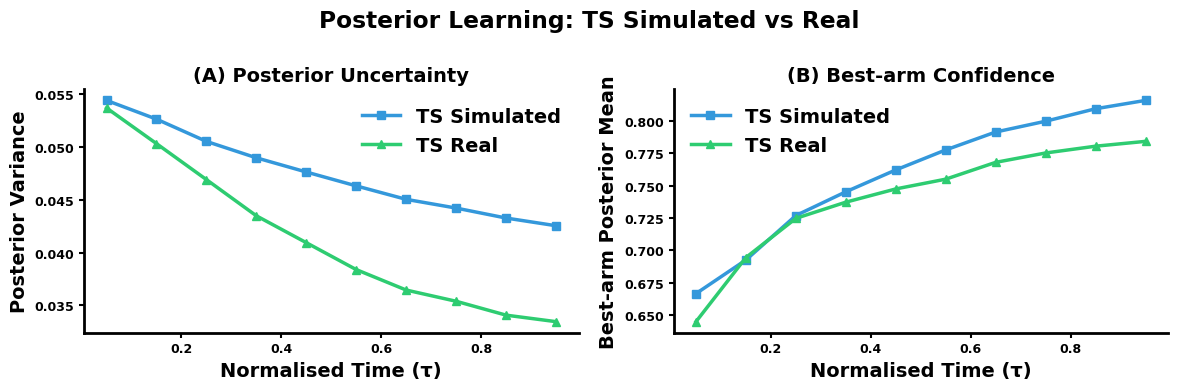

In [ ]:
# ===================== STYLE =====================
SMALL_SIZE = 14
MEDIUM_SIZE = 14

plt.rc('font', size=SMALL_SIZE)
plt.rc('axes', titlesize=SMALL_SIZE)
plt.rc('axes', labelsize=MEDIUM_SIZE)
plt.rc('legend', fontsize=SMALL_SIZE)
plt.rc('axes', linewidth=2)

# ===================== PATHS =====================
RANDOM_PATH = "simulated_random.csv"
SIM_PATH    = "simulated_ts.csv"
REAL_PATH   = "real_world_data.csv"

OUT_DIR = "plots"
import os
os.makedirs(OUT_DIR, exist_ok=True)

# ===================== COLORS =====================
# palette = sns.color_palette("hls", 8)

POLICY_COLORS = {
    'Random': '#E74C3C',
    'TS Simulated': '#3498DB',
    'TS Real': '#2ECC71'
}
POLICY_MARKERS = {
    "Random": 'o',
    "TS Simulated": 's',
    "TS Real": '^'
}

MIN_INTERACTIONS = 6

# ===================== LOAD =====================
def load_data(path, name):
    df = pd.read_csv(path)
    df['Participant_Id'] = df['Participant_Id'].astype(str)
    df['Reward'] = pd.to_numeric(df['Reward'], errors='coerce')
    df = df.dropna(subset=['Reward'])
    df = df[df['Reward'].isin([0, 0.5, 1])].copy()

    df = df.sort_values(['Participant_Id', 'NT_post_Timestamp']).reset_index(drop=True)

    df['_arm'] = df['Intervention']
    df['_activity'] = df['Context']
    df['policy'] = name

    df['t'] = df.groupby('Participant_Id').cumcount()
    return df

df_rand = load_data(RANDOM_PATH, "Random")
df_sim  = load_data(SIM_PATH, "TS Simulated")
df_real = load_data(REAL_PATH, "TS Real")

# ===================== POSTERIOR =====================
def beta_posterior(rewards):
    r = np.asarray(rewards, float)
    alpha = 1 + r.sum()
    beta  = 1 + (1 - r).sum()
    mean  = alpha / (alpha + beta)
    var   = (alpha * beta) / ((alpha + beta)**2 * (alpha + beta + 1))
    return mean, var

def compute_posteriors(df):
    records = []
    arms = sorted(df['_arm'].unique())

    for (uid, act), grp in df.groupby(['Participant_Id','_activity']):
        grp = grp.sort_values('t').reset_index(drop=True)

        if len(grp) < MIN_INTERACTIONS:
            continue

        total = len(grp)
        arm_rewards = {a: [] for a in arms}

        for t, row in grp.iterrows():
            arm_rewards[row['_arm']].append(row['Reward'])

            for a in arms:
                rw = arm_rewards[a]
                if not rw:
                    continue

                mu, var = beta_posterior(rw)

                records.append({
                    'policy': row['policy'],
                    'user': uid,
                    'activity': act,
                    't': t,
                    'tau': t / max(total-1, 1),
                    'arm': a,
                    'posterior_mean': mu,
                    'posterior_var': var
                })

    return pd.DataFrame(records)

print("Computing posteriors...")
post_rand = compute_posteriors(df_rand)
post_sim  = compute_posteriors(df_sim)
post_real = compute_posteriors(df_real)

post_all = pd.concat([post_rand, post_sim, post_real], ignore_index=True)

# ===================== PLOT FUNCTION =====================
def plot_posterior(df, policies, title, filename):

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    tau_bins = np.linspace(0, 1, 11)
    bin_centers = (tau_bins[:-1] + tau_bins[1:]) / 2

    # ---------- (A) Posterior Variance ----------
    ax = axes[0]

    for name in policies:
        sub = df[df['policy'] == name].copy()

        sub['tau_bin'] = pd.cut(sub['tau'], bins=tau_bins, labels=bin_centers)
        sub['tau_bin'] = sub['tau_bin'].astype(float)

        gp = sub.groupby('tau_bin')['posterior_var'].mean().reset_index()

        ax.plot(gp['tau_bin'], gp['posterior_var'],
                color=POLICY_COLORS[name],
                marker=POLICY_MARKERS[name],
                linewidth=2.5, markersize=6, label=name)

    ax.set_xlabel("Normalised Time (τ)", weight='bold')
    ax.set_ylabel("Posterior Variance", weight='bold')
    ax.set_title("(A) Posterior Uncertainty", fontweight='bold')
    ax.legend(frameon=False)

    # ---------- (B) Best Arm Mean ----------
    ax = axes[1]

    for name in policies:
        sub = df[df['policy'] == name].copy()

        best = sub.groupby(['policy','user','activity','t'])['posterior_mean'].max().reset_index()

        best['tau'] = best.groupby(['user','activity'])['t'].transform(
            lambda x: x / max(x.max(), 1)
        )

        best['tau_bin'] = pd.cut(best['tau'], bins=tau_bins, labels=bin_centers)
        best['tau_bin'] = best['tau_bin'].astype(float)

        gp = best.groupby('tau_bin')['posterior_mean'].mean().reset_index()

        ax.plot(gp['tau_bin'], gp['posterior_mean'],
                color=POLICY_COLORS[name],
                marker=POLICY_MARKERS[name],
                linewidth=2.5, markersize=6, label=name)
        
    ax.set_xlabel("Normalised Time (τ)", weight='bold')
    ax.set_ylabel("Best-arm Posterior Mean", weight='bold')
    ax.set_title("(B) Best-arm Confidence", fontweight='bold')
    ax.legend(frameon=False)

    # ---------- STYLE ----------
    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(width=1.5)

    plt.suptitle(title, fontweight='bold')
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

# ===================== PLOTS =====================

# 1. Random vs TS Sim
# plot_posterior(
#     post_all,
#     ["Random", "TS Simulated"],
#     "Posterior Learning: Random vs TS (Simulated)",
#     f"{OUT_DIR}/posterior_random_vs_ts.png"
# )

# 2. TS Sim vs TS Real
plot_posterior(
    post_all,
    ["TS Simulated", "TS Real"],
    "Posterior Learning: TS Simulated vs Real",
    f"{OUT_DIR}/posterior_ts_vs_real.png"
)

In [ ]:
# ===================== LOAD =====================
df_random = pd.read_csv("simulated_random.csv")
df_ts_sim = pd.read_csv("simulated_ts.csv")
df_ts_real = pd.read_csv("real_world_data.csv")

# Clean real data
df_ts_real = df_ts_real[df_ts_real["Reward"].notna()]

# ===================== STANDARDIZE =====================
def prepare(df, name):
    df = df.copy()
    df['Policy'] = name
    df['Context'] = df['Context']
    df['Reward'] = pd.to_numeric(df['Reward'], errors='coerce')
    df = df.dropna(subset=['Reward'])
    return df

df_random = prepare(df_random, "Random")
df_ts_sim = prepare(df_ts_sim, "TS Sim")
df_ts_real = prepare(df_ts_real, "TS Real")

# ===================== FUNCTION =====================
def compute_stats(df):
    return df.groupby('Context').agg(
        mean_reward=('Reward', 'mean'),
        n=('Reward', 'count')
    ).reset_index()

# Compute per policy
rand_stats = compute_stats(df_random)
sim_stats  = compute_stats(df_ts_sim)
real_stats = compute_stats(df_ts_real)

# Rename columns
rand_stats.columns = ['Context', 'Random', 'Random_n']
sim_stats.columns  = ['Context', 'TS Sim', 'TS Sim_n']
real_stats.columns = ['Context', 'TS Real', 'TS Real_n']

# ===================== MERGE =====================
table = rand_stats.merge(sim_stats, on='Context', how='outer')
table = table.merge(real_stats, on='Context', how='outer')

# ===================== ROUND =====================
table['Random'] = table['Random'].round(4)
table['TS Sim'] = table['TS Sim'].round(4)
table['TS Real'] = table['TS Real'].round(4)

# ===================== SORT =====================
table = table.sort_values('Context')

# ===================== SAVE =====================
table.to_csv("activity_comparison_table.csv", index=False)

# ===================== PRINT =====================
print(table.to_string(index=False))

          Context  Random  Random_n  TS Sim  TS Sim_n  TS Real  TS Real_n
Attending Lecture  0.3323      1691  0.7371      1691   0.6433        712
          Cycling  0.1925       678  0.7013       678   0.6447         38
      E-Rick/Auto  0.5565      1337  0.7850      1337   0.6641         64
           Eating  0.4144      1361  0.8575      1361   0.7395        593
         Exercise  0.4568      1030  0.7840      1030   0.7886        175
         Relaxing  0.8091      2032  0.8337      2032   0.5789       3150
          Running  0.2562       726  0.6715       726   0.5959         73
         Standing  0.7060       682  0.8087       682   0.6313        457
         Studying  0.6296      2453  0.7923      2453   0.6367       1873
          Walking  0.5784      1601  0.7976      1601   0.7215       1027


In [ ]:
#%%
import pandas as pd

# ===================== LOAD =====================
df_random = pd.read_csv("simulated_random.csv")
df_ts_sim = pd.read_csv("simulated_ts.csv")
df_ts_real = pd.read_csv("real_world_data.csv")

# ===================== CLEAN =====================
def prepare(df):
    df = df.copy()
    df['Participant_Id'] = df['Participant_Id'].astype(str)
    df['Reward'] = pd.to_numeric(df['Reward'], errors='coerce')
    df = df.dropna(subset=['Reward'])
    return df

df_random = prepare(df_random)
df_ts_sim = prepare(df_ts_sim)
df_ts_real = prepare(df_ts_real)

# ===================== METRICS FUNCTION =====================
def compute_metrics(df):

    total_interactions = len(df)
    unique_users = df['Participant_Id'].nunique()
    mean_reward = df['Reward'].mean()

    # Reward distribution
    r1 = (df['Reward'] == 1).mean() * 100
    r2 = (df['Reward'] == 0.5).mean() * 100
    r3 = (df['Reward'] == 0).mean() * 100

    return {
        "Total Interactions": total_interactions,
        "Unique Users": unique_users,
        "Cumulative Mean Reward": round(mean_reward, 4),
        "Reward 1 % (Yes)": round(r1, 2),
        "Reward 2 % (Yes but not feasible)": round(r2, 2),
        "Reward 3 % (No)": round(r3, 2),
    }

# ===================== COMPUTE =====================
metrics_random = compute_metrics(df_random)
metrics_ts_sim = compute_metrics(df_ts_sim)
metrics_ts_real = compute_metrics(df_ts_real)

# ===================== BUILD TABLE =====================
table = pd.DataFrame({
    "Metric": list(metrics_random.keys()),
    "Random": list(metrics_random.values()),
    "TS Sim": list(metrics_ts_sim.values()),
    "TS Real": list(metrics_ts_real.values()),
})

# ===================== SAVE =====================
table.to_csv("summary_comparison_table.csv", index=False)

# ===================== PRINT =====================
print(table.to_string(index=False))

                           Metric     Random     TS Sim   TS Real
               Total Interactions 13591.0000 13591.0000 8162.0000
                     Unique Users   100.0000   100.0000   70.0000
           Cumulative Mean Reward     0.5337     0.7872    0.6359
                 Reward 1 % (Yes)    47.2200    72.6700   57.8400
Reward 2 % (Yes but not feasible)    12.3000    12.1000   11.5000
                  Reward 3 % (No)    40.4800    15.2200   30.6500


In [7]:
# ===================== DEFINE PHASES =====================
def assign_phase(tau):
    if tau < 1/3:
        return 'Early'
    elif tau < 2/3:
        return 'Mid'
    else:
        return 'Late'

behav_df['phase'] = behav_df['normalized_time'].apply(assign_phase)

# ===================== COMPUTE METRICS =====================
rows = []

for policy in behav_df['policy'].unique():

    sub = behav_df[behav_df['policy'] == policy]

    early_entropy = sub[sub['phase'] == 'Early']['norm_entropy'].mean()
    late_entropy  = sub[sub['phase'] == 'Late']['norm_entropy'].mean()

    entropy_reduction = early_entropy - late_entropy

    max_arm_prob = (1 - sub['norm_entropy']).mean()

    rows.append({
        "Policy": policy,
        "Early Entropy (H~)": round(early_entropy, 4),
        "Late Entropy (H~)": round(late_entropy, 4),
        "Entropy Reduction": round(entropy_reduction, 4),
        "Max Arm Probability (Mean)": round(max_arm_prob, 4)
    })

# ===================== TABLE =====================
table = pd.DataFrame(rows)

# Sort for readability
table = table.sort_values("Policy")

# Save
table.to_csv("behavior_analysis_table.csv", index=False)

# Print
print(table.to_string(index=False))

      Policy  Early Entropy (H~)  Late Entropy (H~)  Entropy Reduction  Max Arm Probability (Mean)
      Random              0.3157             0.5223            -0.2066                      0.5494
     TS Real              0.3451             0.3976            -0.0525                      0.6141
TS Simulated              0.2585             0.3760            -0.1175                      0.6583


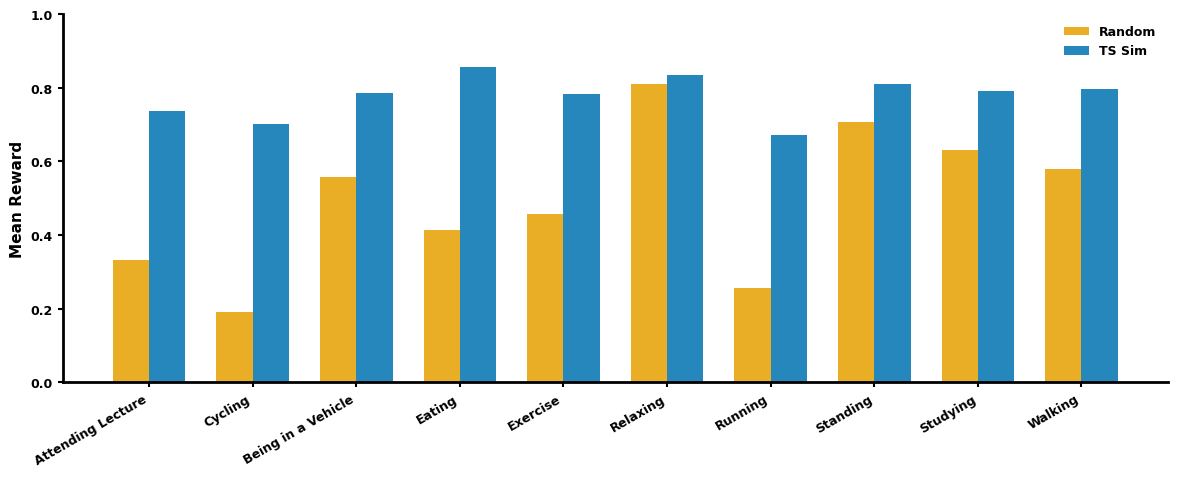

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===================== DATA =====================
data = [
    ["Attending Lecture", 0.3323, 1691, 0.7371, 1691, 0.6433, 712],
    ["Cycling", 0.1925, 678, 0.7013, 678, 0.6447, 38],
    ["Being in a Vehicle", 0.5565, 1337, 0.7850, 1337, 0.6641, 64],
    ["Eating", 0.4144, 1361, 0.8575, 1361, 0.7395, 593],
    ["Exercise", 0.4568, 1030, 0.7840, 1030, 0.7886, 175],
    ["Relaxing", 0.8091, 2032, 0.8337, 2032, 0.5789, 3150],
    ["Running", 0.2562, 726, 0.6715, 726, 0.5959, 73],
    ["Standing", 0.7060, 682, 0.8087, 682, 0.6313, 457],
    ["Studying", 0.6296, 2453, 0.7923, 2453, 0.6367, 1873],
    ["Walking", 0.5784, 1601, 0.7976, 1601, 0.7215, 1027],
]

cols = ["Activity", "Random", "Random_n", "TS Sim", "TS Sim_n", "TS Real", "TS Real_n"]
df = pd.DataFrame(data, columns=cols)

POLICY_COLORS = {
    'Random': '#E69F00',
    'TS Sim': '#0072B2',
    'TS Real': '#009E73'
}

plt.rcParams.update({
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold'
})

def plot_activity(df, policies, title, filename):

    activities = df['Activity']
    x = np.arange(len(activities))
    width = 0.35

    offsets = np.linspace(-width/2, width/2, len(policies))

    fig, ax = plt.subplots(figsize=(12, 5))

    for i, policy in enumerate(policies):
        ax.bar(
            x + offsets[i],
            df[policy],
            width,
            label=policy,
            color=POLICY_COLORS[policy],
            alpha=0.85
        )

    ax.set_xticks(x)
    ax.set_xticklabels(activities, rotation=30, ha='right')
    ax.set_ylabel('Mean Reward')
    # ax.set_title(title)

    ax.set_ylim(0, 1)

    ax.tick_params(width=1.5)
    ax.legend(frameon=False)

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

plot_activity(
    df,
    ['Random', 'TS Sim'],
    'Activity-wise Mean Reward: Random vs Thompson Sampling (Simulated)',
    'activity_random_vs_ts_sim.png'
)

# plot_activity(
#     df,
#     ['TS Sim', 'TS Real'],
#     'Activity-wise Mean Reward: Thompson Sampling (Simulated vs Real)',
#     'activity_ts_sim_vs_real.png'
# )

In [9]:
from scipy.stats import pearsonr, spearmanr

for policy in ['Random', 'TS Sim']:
    r_pearson, p_pearson = pearsonr(df[f"{policy}_n"], df[policy])
    r_spear, p_spear = spearmanr(df[f"{policy}_n"], df[policy])

    print(f"{policy}:")
    print(f"  Pearson r = {r_pearson:.3f}, p = {p_pearson:.4f}")
    print(f"  Spearman ρ = {r_spear:.3f}, p = {p_spear:.4f}")

Random:
  Pearson r = 0.512, p = 0.1301
  Spearman ρ = 0.479, p = 0.1615
TS Sim:
  Pearson r = 0.453, p = 0.1889
  Spearman ρ = 0.406, p = 0.2443


In [12]:
# ── Bootstrap settings ────────────────────────────────────────────────────
N_BOOT = 2000

# ── Bootstrap CI (user-clustered) ─────────────────────────────────────────
def bootstrap_ci(values, n_boot=N_BOOT, ci=95, stat=np.mean, seed=SEED):
    """Clustered bootstrap returning (mean, lower, upper)."""
    rng = np.random.default_rng(seed)
    arr = np.asarray(values, dtype=float)
    arr = arr[~np.isnan(arr)]
    if len(arr) == 0:
        return np.nan, np.nan, np.nan
    boots = [stat(rng.choice(arr, size=len(arr), replace=True)) for _ in range(n_boot)]
    lo = np.percentile(boots, (100 - ci) / 2)
    hi = np.percentile(boots, 100 - (100 - ci) / 2)
    return stat(arr), lo, hi

act_rows = []
for name, df in POLICIES.items():
    for act, grp in df.groupby('_activity'):
        ul = grp.groupby('Participant_Id')['Reward'].mean()
        m, lo, hi = bootstrap_ci(ul.values)
        act_rows.append({
            'Policy': name, 'Activity': act,
            'N_interactions': len(grp),
            'N_users': grp['Participant_Id'].nunique(),
            'Mean Reward': round(m, 4),
            'CI_lo': round(lo, 4),
            'CI_hi': round(hi, 4),
        })

act_df = pd.DataFrame(act_rows)
act_df.to_csv(f'{OUT_DIR}/activity_performance.csv', index=False)
print(act_df.sort_values(['Activity','Policy']).to_string(index=False))


      Policy          Activity  N_interactions  N_users  Mean Reward  CI_lo  CI_hi
      Random Attending Lecture            1691      100       0.3274 0.3059 0.3482
     TS Real Attending Lecture             712       62       0.6422 0.5687 0.7160
TS Simulated Attending Lecture            1691      100       0.7348 0.7115 0.7576
      Random           Cycling             678      100       0.1949 0.1652 0.2263
     TS Real           Cycling              38       19       0.5746 0.3990 0.7588
TS Simulated           Cycling             678      100       0.7015 0.6624 0.7398
      Random       E-Rick/Auto            1337      100       0.5441 0.5145 0.5716
     TS Real       E-Rick/Auto              64       33       0.6641 0.5302 0.7879
TS Simulated       E-Rick/Auto            1337      100       0.7787 0.7537 0.8015
      Random            Eating            1361      100       0.4158 0.3910 0.4397
     TS Real            Eating             593       65       0.7141 0.6421 0.7825
TS S